In [1]:
!pip -q install pandas numpy matplotlib seaborn scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded file(s):")

for filename in uploaded.keys():
    print(filename)

Saving CodeAlpha_Task1_Books_Dataset.csv to CodeAlpha_Task1_Books_Dataset.csv

Uploaded file(s):
CodeAlpha_Task1_Books_Dataset.csv


In [4]:
import glob
import os

csv_files = glob.glob("*.csv")

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file found. Please upload your Task 1 CSV file."
    )

file_path = csv_files[0]

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("File:", file_path)
print("Shape:", df.shape)

Dataset loaded successfully!
File: CodeAlpha_Task1_Books_Dataset.csv
Shape: (999, 8)


In [5]:
print("=" * 70)
print("EDA QUESTIONS")
print("=" * 70)

questions = [
    "1. How many books are present in the dataset?",
    "2. What variables are available and what are their data types?",
    "3. Are there missing values or duplicate records?",
    "4. What is the average and median book price?",
    "5. How are book prices distributed?",
    "6. Which book rating is most common?",
    "7. Does book price differ across rating groups?",
    "8. Is there a relationship between book price and rating?",
    "9. Are there unusually expensive or inexpensive books?",
    "10. What data-quality problems should be addressed?"
]

for question in questions:
    print(question)

EDA QUESTIONS
1. How many books are present in the dataset?
2. What variables are available and what are their data types?
3. Are there missing values or duplicate records?
4. What is the average and median book price?
5. How are book prices distributed?
6. Which book rating is most common?
7. Does book price differ across rating groups?
8. Is there a relationship between book price and rating?
9. Are there unusually expensive or inexpensive books?
10. What data-quality problems should be addressed?


In [6]:
print("FIRST 10 ROWS")
print("=" * 50)

display(df.head(10))

FIRST 10 ROWS


,title,price,rating,availability,image_url,source_page,rating_label,price_range
0,A Light in the Attic,NaN,3,In stock,https://books.toscrape.com/media/cache/2c/da/2...,1,Three Stars,NaN
1,Tipping the Velvet,NaN,1,In stock,https://books.toscrape.com/media/cache/26/0c/2...,1,One Star,NaN
2,Soumission,NaN,1,In stock,https://books.toscrape.com/media/cache/3e/ef/3...,1,One Star,NaN
3,Sharp Objects,NaN,4,In stock,https://books.toscrape.com/media/cache/32/51/3...,1,Four Stars,NaN
4,Sapiens: A Brief History of Humankind,NaN,5,In stock,https://books.toscrape.com/media/cache/be/a5/b...,1,Five Stars,NaN
5,The Requiem Red,NaN,1,In stock,https://books.toscrape.com/media/cache/68/33/6...,1,One Star,NaN
6,The Dirty Little Secrets of Getting Your Dream...,NaN,4,In stock,https://books.toscrape.com/media/cache/92/27/9...,1,Four Stars,NaN
7,The Coming Woman: A Novel Based on the Life of...,NaN,3,In stock,https://books.toscrape.com/media/cache/3d/54/3...,1,Three Stars,NaN
8,The Boys in the Boat: Nine Americans and Their...,NaN,4,In stock,https://books.toscrape.com/media/cache/66/88/6...,1,Four Stars,NaN
9,The Black Maria,NaN,1,In stock,https://books.toscrape.com/media/cache/58/46/5...,1,One Star,NaN


In [7]:
print("LAST 5 ROWS")
print("=" * 50)

display(df.tail())

LAST 5 ROWS


,title,price,rating,availability,image_url,source_page,rating_label,price_range
994,Alice in Wonderland (Alice's Adventures in Won...,NaN,1,In stock,https://books.toscrape.com/media/cache/96/ee/9...,50,One Star,NaN
995,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",NaN,4,In stock,https://books.toscrape.com/media/cache/09/7c/0...,50,Four Stars,NaN
996,A Spy's Devotion (The Regency Spies of London #1),NaN,5,In stock,https://books.toscrape.com/media/cache/1b/5f/1...,50,Five Stars,NaN
997,1st to Die (Women's Murder Club #1),NaN,1,In stock,https://books.toscrape.com/media/cache/2b/41/2...,50,One Star,NaN
998,"1,000 Places to See Before You Die",NaN,5,In stock,https://books.toscrape.com/media/cache/d7/0f/d...,50,Five Stars,NaN


In [8]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 999
Number of columns: 8


In [9]:
print("COLUMN NAMES")
print("=" * 50)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

COLUMN NAMES
1. title
2. price
3. rating
4. availability
5. image_url
6. source_page
7. rating_label
8. price_range


In [10]:
print("DATA TYPES")
print("=" * 50)

data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

display(data_types)

DATA TYPES


,Column,Data Type
0,title,object
1,price,float64
2,rating,int64
3,availability,object
4,image_url,object
5,source_page,int64
6,rating_label,object
7,price_range,float64


In [11]:
print("DATASET INFORMATION")
print("=" * 50)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         999 non-null    object 
 1   price         0 non-null      float64
 2   rating        999 non-null    int64  
 3   availability  999 non-null    object 
 4   image_url     999 non-null    object 
 5   source_page   999 non-null    int64  
 6   rating_label  999 non-null    object 
 7   price_range   0 non-null      float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [12]:
missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percentage
})

display(missing_report)

,Missing Values,Missing Percentage
title,0,0.0
price,999,100.0
rating,0,0.0
availability,0,0.0
image_url,0,0.0
source_page,0,0.0
rating_label,0,0.0
price_range,999,100.0


In [13]:
duplicate_count = df.duplicated().sum()

print(
    "Number of duplicate rows:",
    duplicate_count
)

Number of duplicate rows: 0


In [14]:
print("UNIQUE VALUES")
print("=" * 50)

unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [
        df[column].nunique()
        for column in df.columns
    ]
})

display(unique_values)

UNIQUE VALUES


,Column,Unique Values
0,title,999
1,price,0
2,rating,5
3,availability,1
4,image_url,999
5,source_page,50
6,rating_label,5
7,price_range,0


In [15]:
required_columns = ["title", "price", "rating"]

missing_required = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_required:
    print(
        "Missing required columns:",
        missing_required
    )
else:
    print(
        "All required analysis columns are available."
    )

All required analysis columns are available.


In [17]:
if "price" in df.columns:

    if df["price"].dtype == "object":

        df["price"] = (
            df["price"]
            .astype(str)
            .str.replace("£", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.strip()
        )

    df["price"] = pd.to_numeric(
        df["price"],
        errors="coerce"
    )


# Convert rating to numeric
if "rating" in df.columns:

    df["rating"] = pd.to_numeric(
        df["rating"],
        errors="coerce"
    )


print("Price and rating columns prepared.")

Price and rating columns prepared.


In [18]:
print("STATISTICAL SUMMARY")
print("=" * 50)

display(
    df.describe(include="all")
)

STATISTICAL SUMMARY


,title,price,rating,availability,image_url,source_page,rating_label,price_range
count,999,0.0,999.000000,999,999,999.000000,999,0.0
unique,999,NaN,NaN,1,999,NaN,5,NaN
top,"1,000 Places to See Before You Die",NaN,NaN,In stock,https://books.toscrape.com/media/cache/d7/0f/d...,NaN,One Star,NaN
freq,1,NaN,NaN,999,1,NaN,226,NaN
mean,NaN,NaN,2.920921,NaN,NaN,25.507508,NaN,NaN
std,NaN,NaN,1.434178,NaN,NaN,14.443369,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,NaN
25%,NaN,NaN,2.000000,NaN,NaN,13.000000,NaN,NaN
50%,NaN,NaN,3.000000,NaN,NaN,26.000000,NaN,NaN
75%,NaN,NaN,4.000000,NaN,NaN,38.000000,NaN,NaN


In [19]:
mean_price = df["price"].mean()
median_price = df["price"].median()
min_price = df["price"].min()
max_price = df["price"].max()
std_price = df["price"].std()

print("PRICE ANALYSIS")
print("=" * 50)

print(f"Average price       : £{mean_price:.2f}")
print(f"Median price        : £{median_price:.2f}")
print(f"Minimum price       : £{min_price:.2f}")
print(f"Maximum price       : £{max_price:.2f}")
print(f"Standard deviation  : £{std_price:.2f}")

PRICE ANALYSIS
Average price       : £nan
Median price        : £nan
Minimum price       : £nan
Maximum price       : £nan
Standard deviation  : £nan


In [20]:
print("MEAN VS MEDIAN")
print("=" * 50)

print(f"Mean   : £{mean_price:.2f}")
print(f"Median : £{median_price:.2f}")

if mean_price > median_price:

    print(
        "\nObservation: Mean is higher than median. "
        "This may indicate that higher-priced books "
        "are pulling the average upward."
    )

elif mean_price < median_price:

    print(
        "\nObservation: Mean is lower than median. "
        "This may indicate that lower-priced books "
        "are pulling the average downward."
    )

else:

    print(
        "\nObservation: Mean and median are approximately equal."
    )

MEAN VS MEDIAN
Mean   : £nan
Median : £nan

Observation: Mean and median are approximately equal.


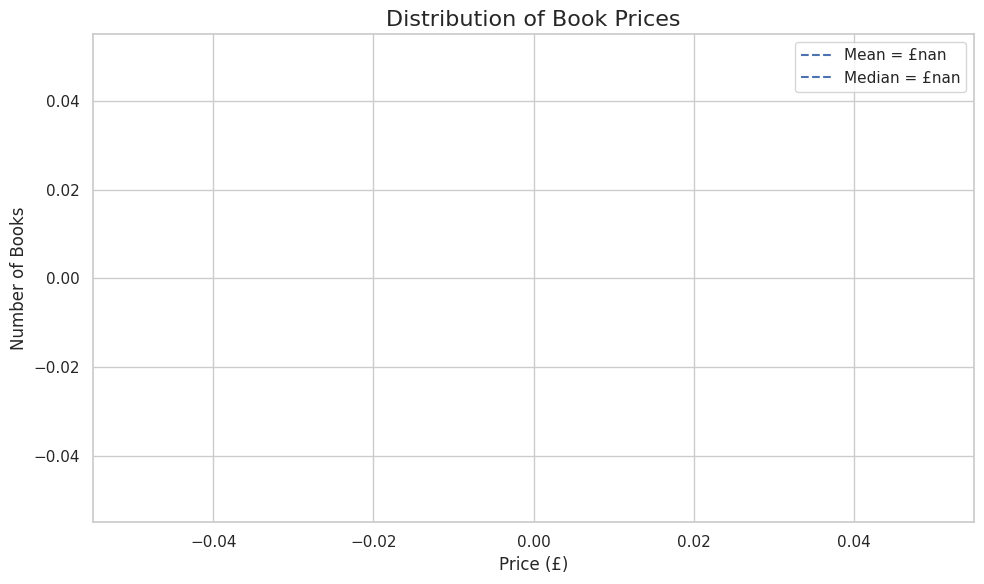

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["price"].dropna(),
    bins=30,
    kde=True
)

plt.axvline(
    mean_price,
    linestyle="--",
    label=f"Mean = £{mean_price:.2f}"
)

plt.axvline(
    median_price,
    linestyle="--",
    label=f"Median = £{median_price:.2f}"
)

plt.title(
    "Distribution of Book Prices",
    fontsize=16
)

plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.legend()

plt.tight_layout()
plt.show()

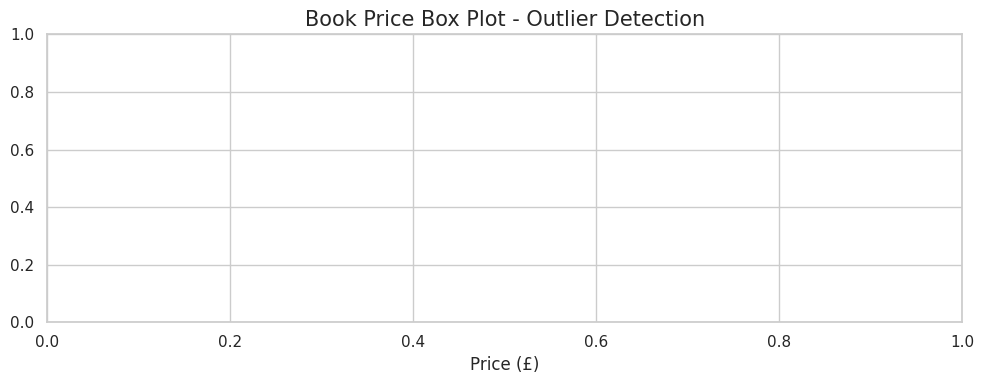

In [22]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["price"].dropna()
)

plt.title(
    "Book Price Box Plot - Outlier Detection",
    fontsize=15
)

plt.xlabel("Price (£)")

plt.tight_layout()
plt.show()

In [23]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))

print(
    "\nLower Bound:",
    round(lower_bound, 2)
)

print(
    "Upper Bound:",
    round(upper_bound, 2)
)

print(
    "\nPotential price outliers:",
    len(outliers)
)

Q1: nan
Q3: nan
IQR: nan

Lower Bound: nan
Upper Bound: nan

Potential price outliers: 0


In [24]:
if len(outliers) > 0:

    columns_to_show = [
        column
        for column in ["title", "price", "rating"]
        if column in df.columns
    ]

    display(
        outliers[
            columns_to_show
        ].sort_values(
            "price",
            ascending=False
        )
    )

else:

    print("No potential price outliers detected.")

No potential price outliers detected.


In [25]:
rating_counts = (
    df["rating"]
    .value_counts()
    .sort_index()
)

print("RATING DISTRIBUTION")
print("=" * 50)

display(
    rating_counts.to_frame(
        "Number of Books"
    )
)

RATING DISTRIBUTION


,Number of Books
rating,
1,226
2,196
3,203
4,179
5,195


In [26]:
most_common_rating = df["rating"].mode().iloc[0]

print(
    f"Most common rating: "
    f"{int(most_common_rating)}/5"
)

Most common rating: 1/5


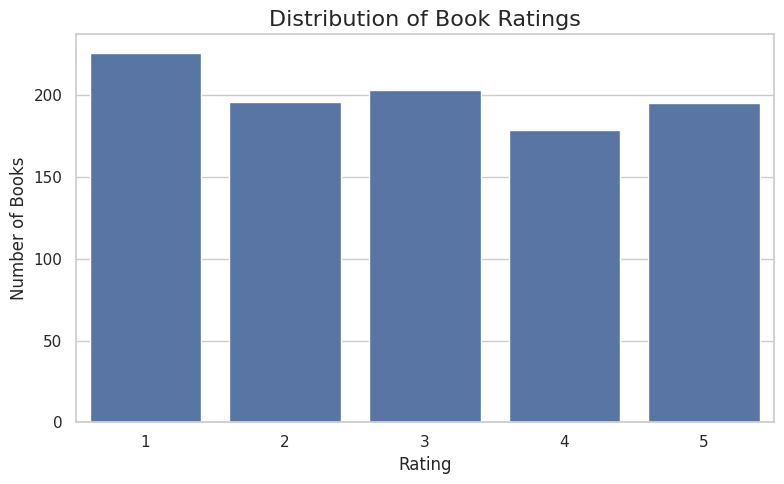

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="rating",
    order=sorted(
        df["rating"].dropna().unique()
    )
)

plt.title(
    "Distribution of Book Ratings",
    fontsize=16
)

plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

In [28]:
price_rating_summary = (
    df.groupby("rating")["price"]
    .agg(
        Number_of_Books="count",
        Average_Price="mean",
        Median_Price="median",
        Minimum_Price="min",
        Maximum_Price="max"
    )
    .round(2)
)

display(price_rating_summary)

,Number_of_Books,Average_Price,Median_Price,Minimum_Price,Maximum_Price
rating,,,,,
1,0,NaN,NaN,NaN,NaN
2,0,NaN,NaN,NaN,NaN
3,0,NaN,NaN,NaN,NaN
4,0,NaN,NaN,NaN,NaN
5,0,NaN,NaN,NaN,NaN


In [33]:
plot_df = df[["rating", "price"]].copy()

plot_df["rating"] = pd.to_numeric(plot_df["rating"], errors="coerce")
plot_df["price"] = pd.to_numeric(plot_df["price"], errors="coerce")

# Remove rows with missing values
plot_df = plot_df.dropna(subset=["rating", "price"])

# Check whether data is available
if plot_df.empty:
    print("No valid numeric data available for the boxplot.")
else:
    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=plot_df,
        x="rating",
        y="price"
    )

    plt.title("Price Distribution by Book Rating")
    plt.xlabel("Rating")
    plt.ylabel("Price (£)")
    plt.tight_layout()
    plt.show()

No valid numeric data available for the boxplot.


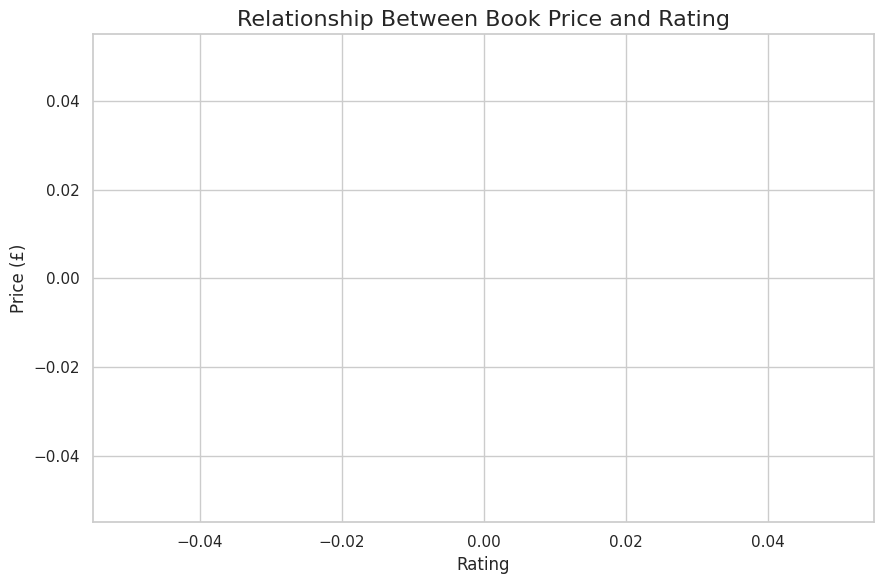

In [34]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="rating",
    y="price",
    alpha=0.6
)

plt.title(
    "Relationship Between Book Price and Rating",
    fontsize=16
)

plt.xlabel("Rating")
plt.ylabel("Price (£)")

plt.tight_layout()
plt.show()

In [35]:
correlation = df[
    ["price", "rating"]
].corr().loc[
    "price",
    "rating"
]

print(
    f"Pearson correlation: {correlation:.3f}"
)

Pearson correlation: nan


In [36]:
abs_corr = abs(correlation)

if abs_corr < 0.2:
    strength = "very weak"

elif abs_corr < 0.4:
    strength = "weak"

elif abs_corr < 0.6:
    strength = "moderate"

elif abs_corr < 0.8:
    strength = "strong"

else:
    strength = "very strong"


if correlation > 0:
    direction = "positive"

elif correlation < 0:
    direction = "negative"

else:
    direction = "no"


print(
    f"The relationship is {strength} and {direction}."
)

The relationship is very strong and no.


In [37]:
rating_groups = []

for rating_value in sorted(
    df["rating"].dropna().unique()
):

    group = df.loc[
        df["rating"] == rating_value,
        "price"
    ].dropna()

    if len(group) > 1:
        rating_groups.append(group.values)


if len(rating_groups) >= 2:

    anova_result = stats.f_oneway(
        *rating_groups
    )

    print(
        "F-statistic:",
        round(
            anova_result.statistic,
            4
        )
    )

    print(
        "P-value:",
        anova_result.pvalue
    )

else:

    print(
        "ANOVA could not be performed because "
        "there are not enough rating groups."
    )

ANOVA could not be performed because there are not enough rating groups.


In [38]:
if len(rating_groups) >= 2:

    alpha = 0.05

    print(
        f"Significance level: {alpha}"
    )

    if anova_result.pvalue < alpha:

        print(
            "\nDecision: Reject H0."
        )

        print(
            "There is statistically significant evidence "
            "that average prices differ between at least "
            "some rating groups."
        )

    else:

        print(
            "\nDecision: Fail to reject H0."
        )

        print(
            "There is not enough statistical evidence "
            "to conclude that average prices differ "
            "between rating groups."
        )

In [39]:
df["price_range"] = pd.cut(
    df["price"],
    bins=[
        0,
        20,
        30,
        40,
        50,
        np.inf
    ],
    labels=[
        "Under £20",
        "£20-£30",
        "£30-£40",
        "£40-£50",
        "Over £50"
    ],
    right=False
)

price_range_counts = (
    df["price_range"]
    .value_counts()
    .sort_index()
)

display(
    price_range_counts.to_frame(
        "Number of Books"
    )
)

,Number of Books
price_range,
Under £20,0
£20-£30,0
£30-£40,0
£40-£50,0
Over £50,0


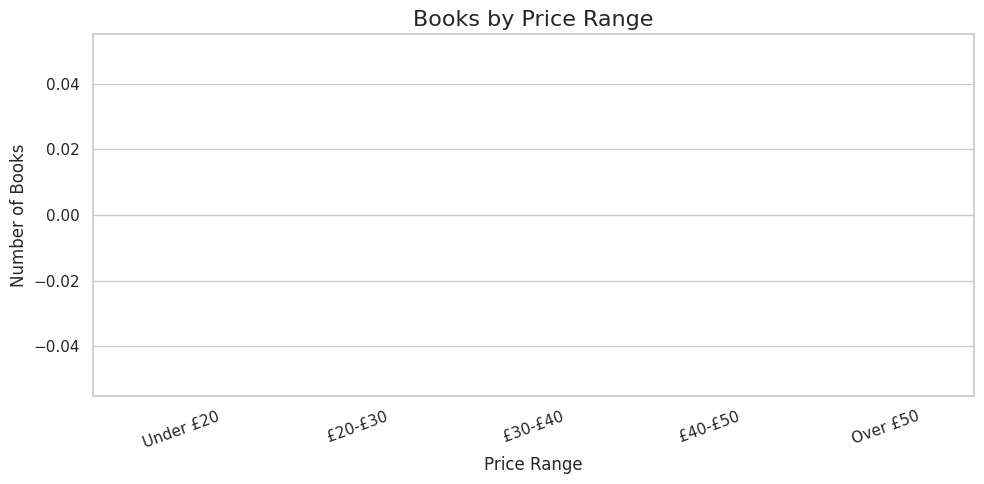

In [40]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="price_range",
    order=df["price_range"].cat.categories
)

plt.title(
    "Books by Price Range",
    fontsize=16
)

plt.xlabel("Price Range")
plt.ylabel("Number of Books")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

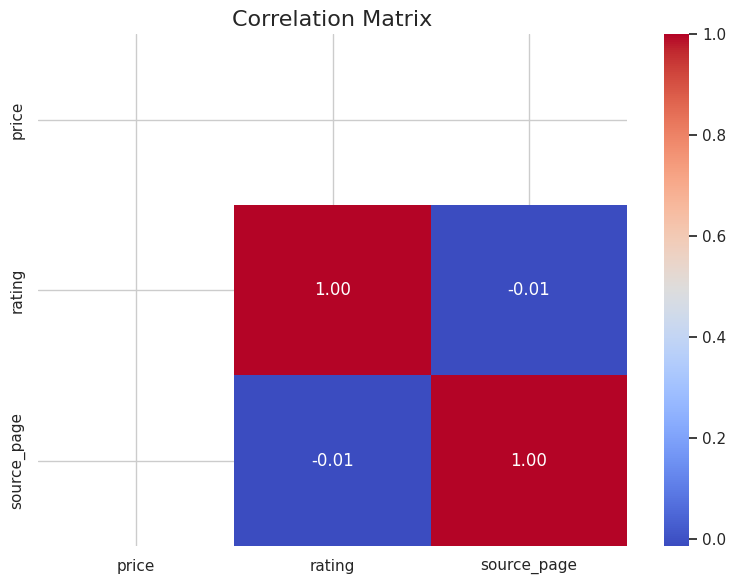

In [41]:
numeric_df = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [42]:
negative_prices = (
    (df["price"] < 0).sum()
)

zero_prices = (
    (df["price"] == 0).sum()
)

unique_titles = (
    df["title"].nunique()
    if "title" in df.columns
    else "N/A"
)

total_missing = (
    df.isnull().sum().sum()
)

print("=" * 70)
print("FINAL DATA QUALITY REPORT")
print("=" * 70)

print(
    f"\nTotal records: {len(df)}"
)

print(
    f"Total variables: {len(df.columns)}"
)

print(
    f"Duplicate records: {df.duplicated().sum()}"
)

print(
    f"Total missing values: {total_missing}"
)

print(
    f"Negative prices: {negative_prices}"
)

print(
    f"Zero prices: {zero_prices}"
)

print(
    f"Unique book titles: {unique_titles}"
)

print(
    f"Potential price outliers: {len(outliers)}"
)

print("=" * 70)

FINAL DATA QUALITY REPORT

Total records: 999
Total variables: 8
Duplicate records: 0
Total missing values: 1998
Negative prices: 0
Zero prices: 0
Unique book titles: 999
Potential price outliers: 0


In [43]:
print("=" * 80)
print("             CODEALPHA DATA ANALYTICS INTERNSHIP")
print("                     TASK 2 - EDA")
print("=" * 80)

print("\nDATASET OVERVIEW")
print("-" * 80)

print(
    f"Records: {len(df):,}"
)

print(
    f"Variables: {len(df.columns)}"
)

print(
    f"Average price: £{df['price'].mean():.2f}"
)

print(
    f"Median price: £{df['price'].median():.2f}"
)

print(
    f"Average rating: {df['rating'].mean():.2f}/5"
)

print(
    f"Most common rating: {int(most_common_rating)}/5"
)

print(
    f"Price-rating correlation: {correlation:.3f}"
)

print(
    f"Potential price outliers: {len(outliers)}"
)

print(
    f"Duplicate records: {df.duplicated().sum()}"
)

print(
    f"Missing values: {df.isnull().sum().sum()}"
)

print("\nHYPOTHESIS TEST")
print("-" * 80)

if len(rating_groups) >= 2:

    print(
        f"ANOVA p-value: "
        f"{anova_result.pvalue:.6f}"
    )

    if anova_result.pvalue < 0.05:
        print(
            "Conclusion: Reject H0 at the 5% significance level."
        )
    else:
        print(
            "Conclusion: Fail to reject H0 at the 5% significance level."
        )

print("\nDATA QUALITY")
print("-" * 80)

if total_missing == 0:
    print("No missing values detected.")

else:
    print(
        f"{total_missing} missing values detected."
    )

if df.duplicated().sum() == 0:
    print("No duplicate records detected.")

else:
    print(
        f"{df.duplicated().sum()} duplicate records detected."
    )

print("=" * 80)

             CODEALPHA DATA ANALYTICS INTERNSHIP
                     TASK 2 - EDA

DATASET OVERVIEW
--------------------------------------------------------------------------------
Records: 999
Variables: 8
Average price: £nan
Median price: £nan
Average rating: 2.92/5
Most common rating: 1/5
Price-rating correlation: nan
Potential price outliers: 0
Duplicate records: 0
Missing values: 1998

HYPOTHESIS TEST
--------------------------------------------------------------------------------

DATA QUALITY
--------------------------------------------------------------------------------
1998 missing values detected.
No duplicate records detected.


In [44]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Variables",
        "Average Price",
        "Median Price",
        "Minimum Price",
        "Maximum Price",
        "Average Rating",
        "Most Common Rating",
        "Price-Rating Correlation",
        "Potential Price Outliers",
        "Duplicate Records",
        "Total Missing Values"
    ],

    "Value": [
        len(df),
        len(df.columns),
        round(df["price"].mean(), 2),
        round(df["price"].median(), 2),
        round(df["price"].min(), 2),
        round(df["price"].max(), 2),
        round(df["rating"].mean(), 2),
        int(most_common_rating),
        round(correlation, 3),
        len(outliers),
        df.duplicated().sum(),
        df.isnull().sum().sum()
    ]
})

display(eda_summary)

eda_summary.to_csv(
    "CodeAlpha_Task2_EDA_Summary.csv",
    index=False
)

print(
    "\nEDA summary saved successfully!"
)

,Metric,Value
0,Total Records,999.00
1,Total Variables,8.00
2,Average Price,NaN
3,Median Price,NaN
4,Minimum Price,NaN
5,Maximum Price,NaN
6,Average Rating,2.92
7,Most Common Rating,1.00
8,Price-Rating Correlation,NaN
9,Potential Price Outliers,0.00



EDA summary saved successfully!
